In [131]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [132]:
df = pd.read_csv("./car_evaluation.csv", header=None)
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1728 non-null   object
 1   1       1728 non-null   object
 2   2       1728 non-null   object
 3   3       1728 non-null   object
 4   4       1728 non-null   object
 5   5       1728 non-null   object
 6   6       1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [133]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [134]:
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df.columns = columns

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [135]:
for col in df.columns:
  print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [136]:
# feature matrix
X = df.drop(columns=["class"])

# target array
y = df["class"]

# saving 20% data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=1)

# we need to encode the features to whole numbers, target array need not to be encoded, handled implicitly
oe = OrdinalEncoder()
X_train_encoded = oe.fit_transform(X_train)
X_test_encoded = oe.transform(X_test)

oe.feature_names_in_
# array(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'],
#       dtype=object)

oe.categories_
# [array(['high', 'low', 'med', 'vhigh'], dtype=object),
#  array(['high', 'low', 'med', 'vhigh'], dtype=object),
#  array(['2', '3', '4', '5more'], dtype=object),
#  array(['2', '4', 'more'], dtype=object),
#  array(['big', 'med', 'small'], dtype=object),
#  array(['high', 'low', 'med'], dtype=object)]

X_train_encoded # numpy ndarray

array([[1., 2., 2., 1., 1., 2.],
       [0., 0., 3., 1., 1., 2.],
       [3., 2., 3., 0., 2., 0.],
       ...,
       [2., 2., 0., 1., 0., 2.],
       [3., 2., 0., 2., 2., 2.],
       [2., 0., 3., 0., 0., 0.]], shape=(1382, 6))

In [137]:
# model instantiation
model = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=9)

# model training
model.fit(X_train_encoded, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# I want to see how well the model performs on training data.

y_train_pred = model.predict(X_train_encoded)

y_train_pred
# array(['unacc', 'unacc', 'unacc', ..., 'unacc', 'unacc', 'acc'],
#       shape=(1382,), dtype=object)

# calculating the accuracy score for training data
training_data_accuracy_score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy score of trained model on training data is { training_data_accuracy_score }")

# When I didn't set the max-depth parameter while declaring the model I got accuracy on training data 100%. Clearly a sign of overfitting.
# I set max-depth=5, accuracy of model on training data becomes 87.33719247467439%
# I set max-depth=4, accuracy of model on training data becomes 82.48914616497829%
# I set max-depth=3, accuracy of model on training data becomes 77.49638205499276%
# I set max-depth=7, accuracy of model on training data becomes 92.98118668596237%
# I set max-depth=8, accuracy of model on training data becomes 95.1519536903039%
# I set max-depth=9, accuracy of model on training data becomes 97.61215629522432%

Accuracy score of trained model on training data is 0.9761215629522432


In [ ]:
# Now I want to see how well the moodel performs on testing data.

y_test_pred = model.predict(X_test_encoded)

# calculating the accuracy score of model for testing data.
testing_data_accuracy_score = accuracy_score(y_test, y_test_pred)
print(f"Accuracy score of trained model on testing data is { testing_data_accuracy_score }")

# When I didn't set the max-depth parameter while declaring the model I got accuracy on testing data 98.26589595375722%
# I set max-depth=5, accuracy of model on testing data becomes 86.9942196531792%
# I set max-depth=4, accuracy of model on testing data becomes 82.65895953757225%
# I set max-depth=3, accuracy of model on testing data becomes 78.90173410404624%
# I set max-depth=7, accuracy of model on testing data becomes 93.0635838150289%
# I set max-depth=8, accuracy of model on testing data becomes 92.19653179190751%
# I set max-depth=9, accuracy of model on testing data becomes 93.93063583815029%

# I think max-depth=7 is most appropriate since after increasing it the accuracy score for training data increases and for testing data decreases. Also the accuray scores are comparable.
# May be s

Accuracy score of trained model on testing data is 0.9393063583815029


[Text(0.5574776785714286, 0.95, 'x[3] <= 0.5\nentropy = 1.226\nsamples = 1382\nvalue = [325, 55, 950, 52]'),
 Text(0.5396205357142857, 0.85, 'entropy = 0.0\nsamples = 452\nvalue = [0, 0, 452, 0]'),
 Text(0.5485491071428572, 0.8999999999999999, 'True  '),
 Text(0.5753348214285714, 0.85, 'x[5] <= 0.5\nentropy = 1.486\nsamples = 930\nvalue = [325.0, 55.0, 498.0, 52.0]'),
 Text(0.56640625, 0.8999999999999999, '  False'),
 Text(0.34598214285714285, 0.75, 'x[1] <= 2.5\nentropy = 1.643\nsamples = 325\nvalue = [181.0, 24.0, 68.0, 52.0]'),
 Text(0.24553571428571427, 0.65, 'x[0] <= 2.5\nentropy = 1.633\nsamples = 241\nvalue = [137, 24, 28, 52]'),
 Text(0.13392857142857142, 0.55, 'x[0] <= 0.5\nentropy = 1.561\nsamples = 176\nvalue = [94, 24, 6, 52]'),
 Text(0.05357142857142857, 0.45, 'x[2] <= 0.5\nentropy = 0.29\nsamples = 59\nvalue = [56, 0, 3, 0]'),
 Text(0.03571428571428571, 0.35, 'x[4] <= 1.5\nentropy = 0.696\nsamples = 16\nvalue = [13, 0, 3, 0]'),
 Text(0.017857142857142856, 0.25, 'entropy =

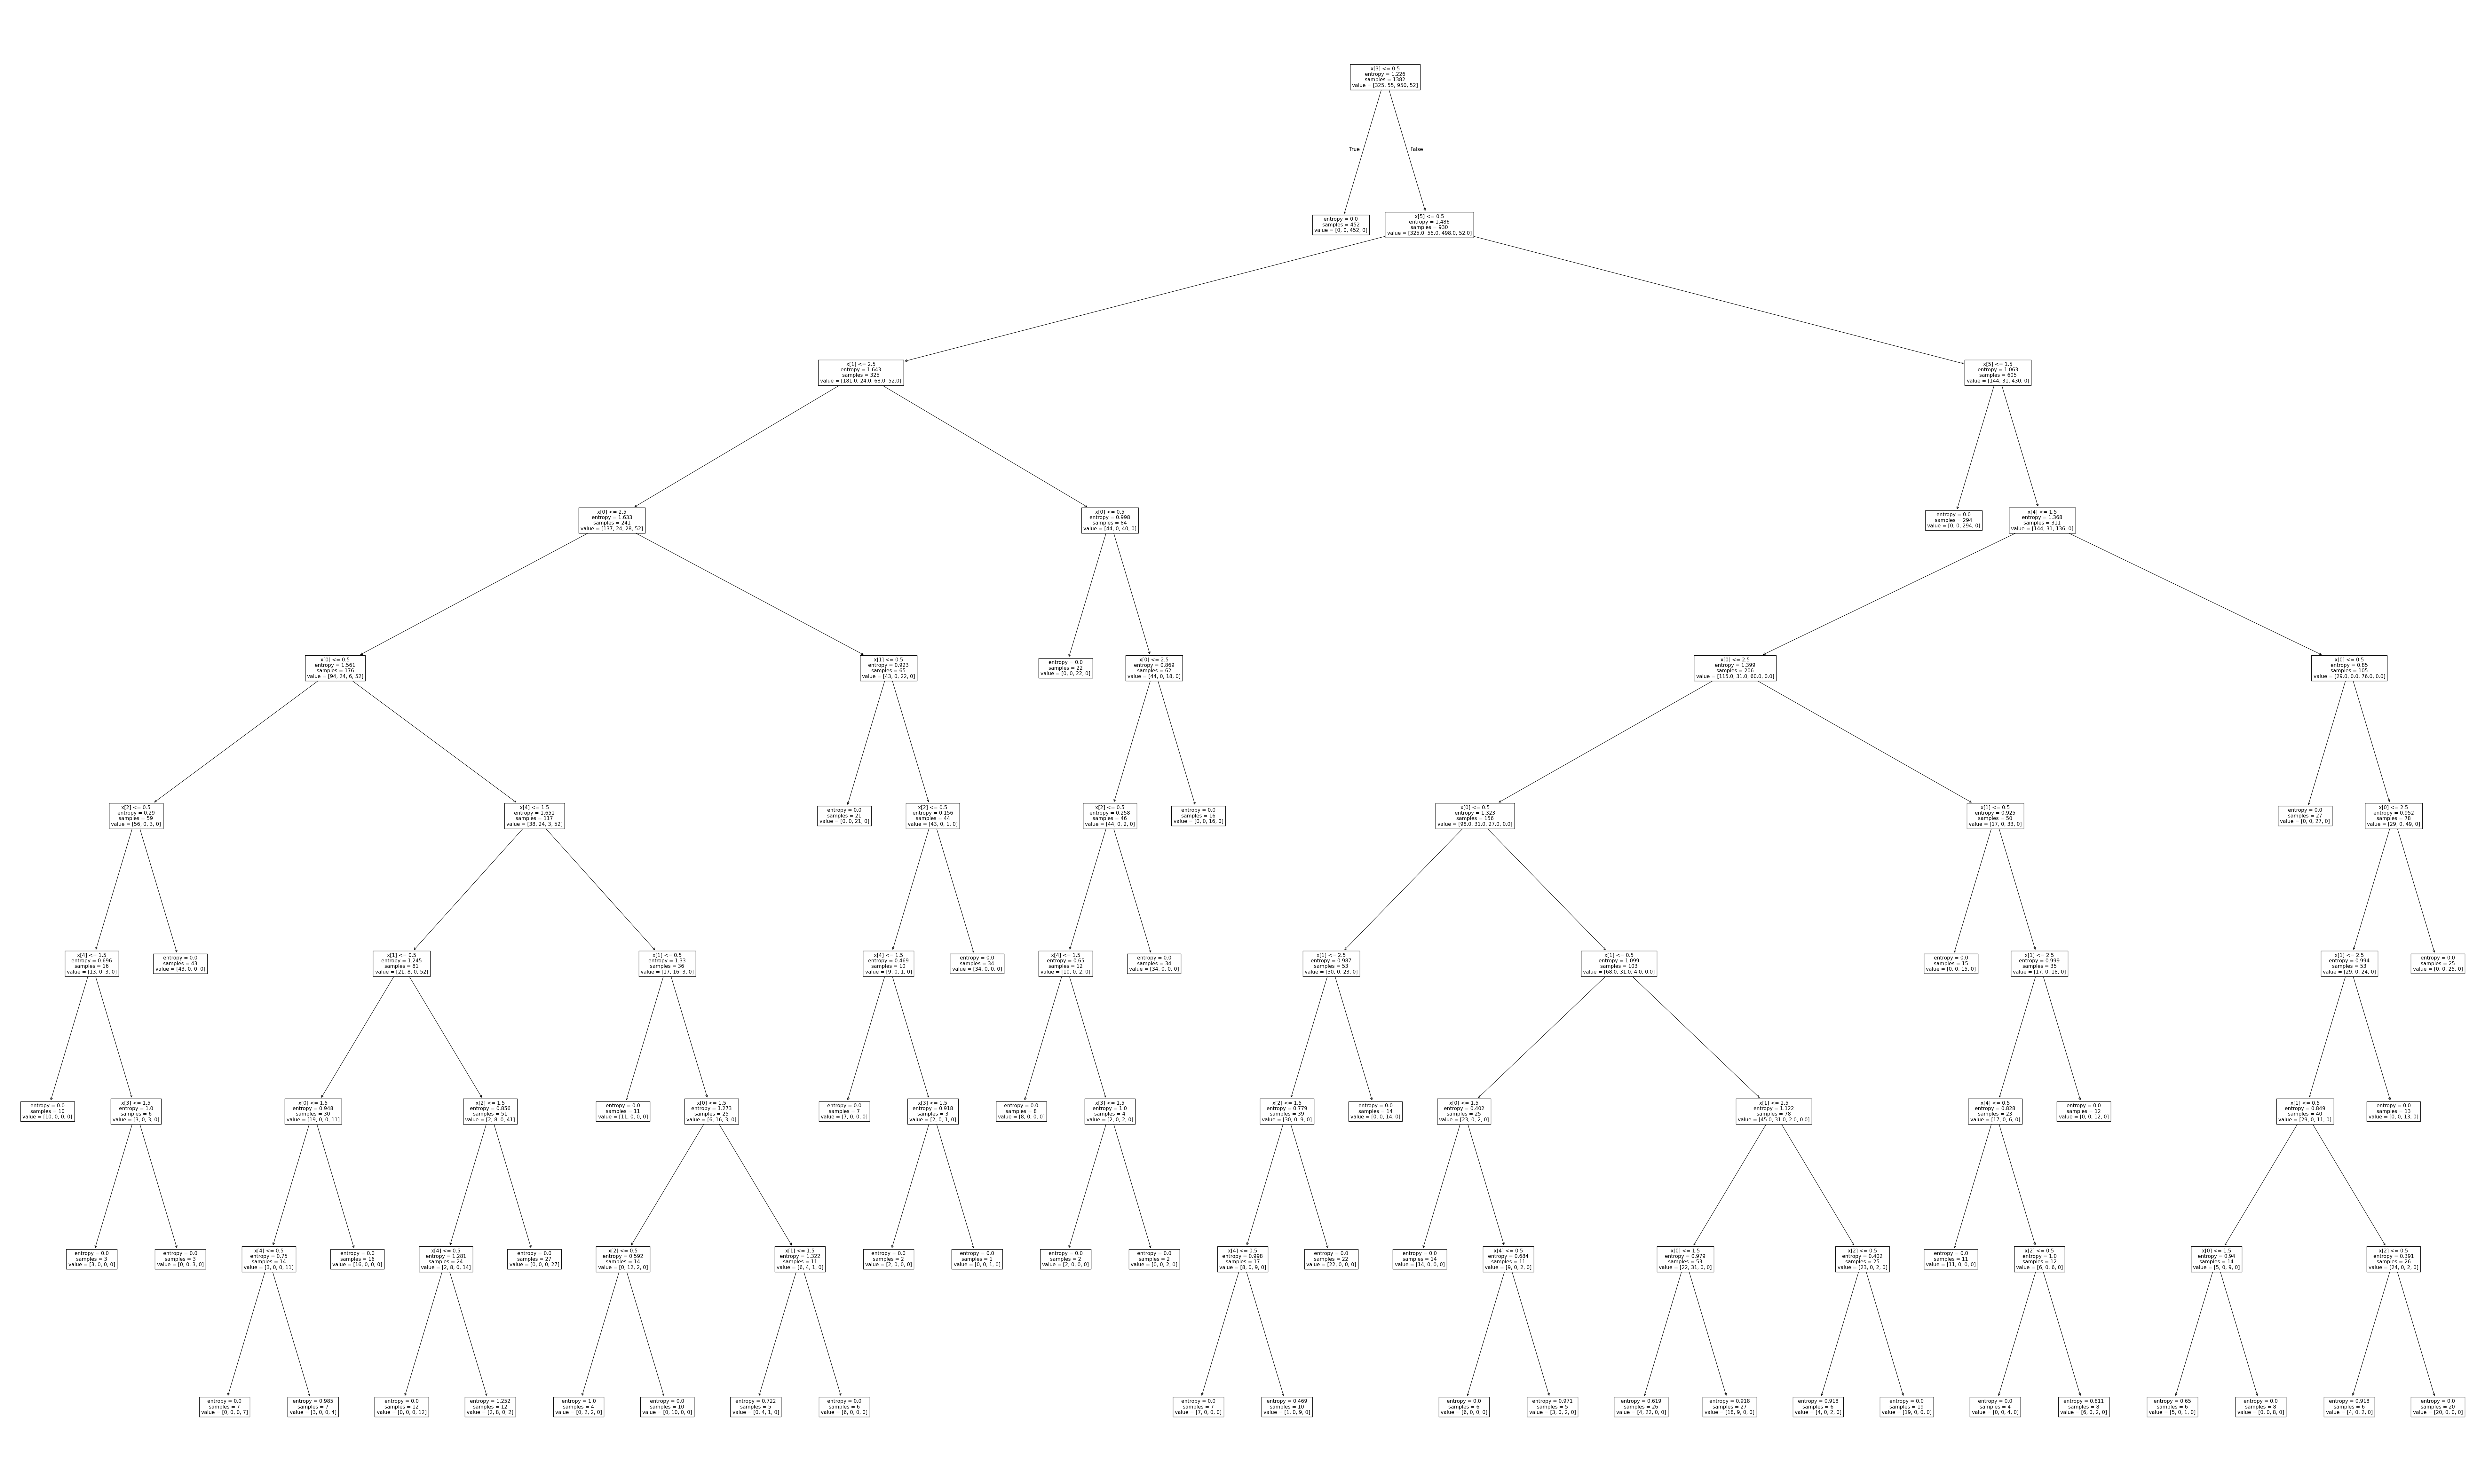

In [140]:
plt.figure(figsize=(100, 60))
plot_tree(model)